# Y.Afisha — análise de marketing e economia unitária

Análise de produto, vendas e aquisição de usuários para avaliar a eficiência dos investimentos em marketing. O projeto acompanha uso do produto, retenção, conversão, LTV, CAC e ROMI por fonte de aquisição.

**Ferramentas:** Python, pandas, numpy, matplotlib e seaborn.


## Preparação dos dados

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

### Visualizando, otimizando e carregando planilhas

**Planilha visits (logs do servidor com dados sobre os acessos ao site)**

In [2]:
visits = pd.read_csv('data/visits_log_us.csv', nrows=500)


In [3]:
print(visits.info(memory_usage='deep'))
print(visits.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Device     500 non-null    object
 1   End Ts     500 non-null    object
 2   Source Id  500 non-null    int64 
 3   Start Ts   500 non-null    object
 4   Uid        500 non-null    uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 101.4 KB
None
    Device               End Ts  ...             Start Ts                   Uid
0    touch  2017-12-20 17:38:00  ...  2017-12-20 17:20:00  16879256277535980062
1  desktop  2018-02-19 17:21:00  ...  2018-02-19 16:53:00    104060357244891740
2    touch  2017-07-01 01:54:00  ...  2017-07-01 01:54:00   7459035603376831527
3  desktop  2018-05-20 11:23:00  ...  2018-05-20 10:59:00  16174680259334210214
4  desktop  2017-12-27 14:06:00  ...  2017-12-27 14:06:00   9969694820036681168

[5 rows x 5 columns]


In [4]:
visits = pd.read_csv('data/visits_log_us.csv', dtype={'Device':'category'}, parse_dates=['Start Ts', 'End Ts'])
visits.columns = ['device', 'end_ts', 'source_id', 'start_ts','uid']
visits.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB


**Planilha orders (dados sobre os pedidos)**

In [5]:
orders = pd.read_csv('data/orders_log_us.csv', nrows=500)


In [6]:
print(orders.info(memory_usage='deep'))
print(orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   500 non-null    object 
 1   Revenue  500 non-null    float64
 2   Uid      500 non-null    uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 41.1 KB
None
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


In [7]:
orders = pd.read_csv('data/orders_log_us.csv', parse_dates=['Buy Ts'])
orders.columns = ['buy_ts', 'revenue', 'uid']
orders.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


**Planilha costs (dados sobre as despesas com marketing)**

In [8]:
costs = pd.read_csv('data/costs_us.csv', nrows=500)


In [9]:
print(costs.info(memory_usage='deep'))
print(costs.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  500 non-null    int64  
 1   dt         500 non-null    object 
 2   costs      500 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 36.8 KB
None
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08


In [10]:
#verificando se source_id é coluna categórica

print(costs['source_id'].unique())

# é categórica

[1 2]


In [11]:
costs = pd.read_csv(
    'data/costs_us.csv',
    dtype={'source_id': 'category'},
    parse_dates=['dt']
)

costs.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   category      
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 43.0 KB


### Informação sobre dados

* Algumas colunas foram transformadas de `object` em `datetime64` e `category` para fins de otimização dos dados.
* Algumas colunas foram renomeadas para retirar letras maiúsculas e inserir underlines.
* A seguir, verifico explicitamente valores ausentes e linhas duplicadas nas três tabelas.

In [12]:
for nome, df in [('visits', visits), ('orders', orders), ('costs', costs)]:
    print(nome, '| duplicadas:', df.duplicated().sum(), '| ausentes:', df.isna().sum().sum())

visits | duplicadas: 0 | ausentes: 0
orders | duplicadas: 0 | ausentes: 0
costs | duplicadas: 0 | ausentes: 0


## Relatórios e métricas

### Produto: Quantas pessoas usam-no cada dia, semana e mês?

In [13]:
visits['year_of_visits'] = visits['start_ts'].dt.year
visits['month_of_visits'] = visits['start_ts'].dt.month
visits['week_of_visits'] = visits['start_ts'].dt.isocalendar().week
visits['day_of_visits'] = visits['start_ts'].dt.date

visits.head()

,device,end_ts,source_id,start_ts,uid,year_of_visits,month_of_visits,week_of_visits,day_of_visits
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017,12,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018,2,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017,7,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018,5,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017,12,52,2017-12-27


In [14]:
visits_by_month = visits.groupby(['year_of_visits', 'month_of_visits']).agg({'uid': 'nunique'})
visits_by_week = visits.groupby(['year_of_visits', 'week_of_visits']).agg({'uid': 'nunique'})
visits_by_day = visits.groupby(['day_of_visits']).agg({'uid': 'nunique'})

In [15]:
print(visits_by_month.sort_values(by='uid', ascending=False))
print(visits_by_week.sort_values(by='uid', ascending=False))
print(visits_by_day.sort_values(by='uid', ascending=False).head(20))

                                  uid
year_of_visits month_of_visits       
2017           11               32797
               12               31557
               10               29692
2018           2                28749
               1                28716
               3                27473
               4                21008
               5                20701
2017           9                18975
               7                14183
               6                13259
               8                11631
                                 uid
year_of_visits week_of_visits       
2017           47              10586
               49               8407
               50               8214
               48               8166
               46               8117
2018           5                8111
               6                7908
               12               7898
2017           52               7774
2018           7                7759
2017           40       

DAU: 908 | WAU: 5716 | MAU: 23228


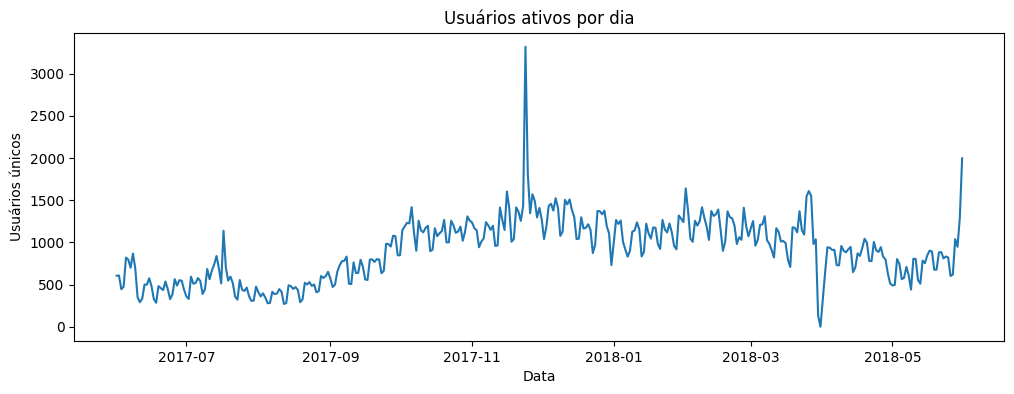

In [16]:
dau = visits_by_day['uid'].mean()
wau = visits_by_week['uid'].mean()
mau = visits_by_month['uid'].mean()
print(f'DAU: {dau:.0f} | WAU: {wau:.0f} | MAU: {mau:.0f}')

visits_by_day['uid'].plot(figsize=(12,4), title='Usuários ativos por dia', xlabel='Data', ylabel='Usuários únicos')
plt.show()

In [17]:
for ano, semana in [(2018, 12), (2017, 40), (2018, 8)]:
    print(ano, semana, pd.Timestamp.fromisocalendar(ano, semana, 1).date())

2018 12 2018-03-19
2017 40 2017-10-02
2018 8 2018-02-19


#### Interpretação dos dados

* Em média, o produto registra aproximadamente **908 usuários ativos por dia (DAU)**, **5.716 por semana (WAU)** e **23.228 por mês (MAU)**.
* Ao longo do período analisado, a atividade se concentra principalmente entre outubro e março.
* O maior pico diário ocorre em **24/11/2017**, data da Black Friday de 2017, o que pode ajudar a explicar o aumento excepcional de acessos.

### Produto: Quantas sessões ocorrem por dia?

In [18]:
sessions_by_day = visits.groupby(['day_of_visits']).agg({'uid': 'count'})
sessions_by_day = sessions_by_day.rename(columns={'uid': 'n_sessions'})
print(sessions_by_day.sort_values(by='n_sessions', ascending=False))
print(sessions_by_day['n_sessions'].mean())

               n_sessions
day_of_visits            
2017-11-24           4042
2018-05-31           2256
2017-11-25           2089
2018-02-01           1878
2018-03-26           1796
...                   ...
2017-08-06            296
2017-08-12            296
2017-08-13            293
2018-03-30            134
2018-03-31              1

[364 rows x 1 columns]
987.3626373626373


#### Interpretação dos dados

O produto registra em média aproximadamente **987 sessões por dia**. O maior pico ocorre em **24/11/2017**, data da Black Friday de 2017, com **4.042 sessões**, mais de quatro vezes a média diária.

### Produto: Quanto dura cada sessão?


In [19]:
visits['session_sizes'] = (visits['end_ts'] - visits['start_ts']).dt.seconds
visits['session_sizes'].head()

0    1080
1    1680
2       0
3    1440
4       0
Name: session_sizes, dtype: int32

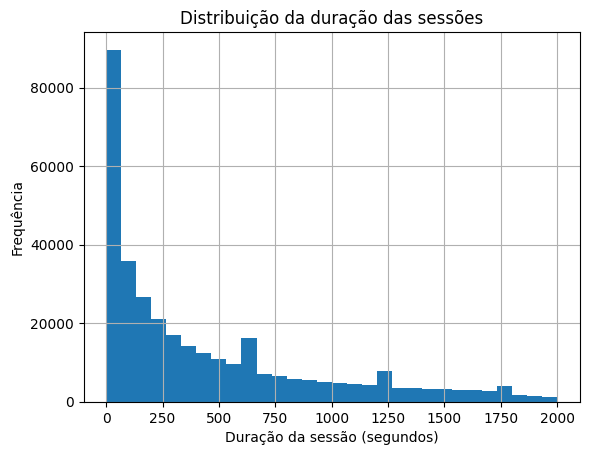

In [20]:
visits['session_sizes'].hist(bins=30, range=(0,2000))
plt.title('Distribuição da duração das sessões')
plt.xlabel('Duração da sessão (segundos)')
plt.ylabel('Frequência')
plt.show()

In [21]:
visits['session_sizes'].value_counts().sort_values(ascending=False)

session_sizes
60       53029
0        35794
120      35748
180      26672
240      21085
         ...  
18660        1
17220        1
23520        1
11700        1
16800        1
Name: count, Length: 312, dtype: int64

In [22]:
visits[['end_ts', 'start_ts']].head()

,end_ts,start_ts
0,2017-12-20 17:38:00,2017-12-20 17:20:00
1,2018-02-19 17:21:00,2018-02-19 16:53:00
2,2017-07-01 01:54:00,2017-07-01 01:54:00
3,2018-05-20 11:23:00,2018-05-20 10:59:00
4,2017-12-27 14:06:00,2017-12-27 14:06:00


In [23]:
# encontrando mediana, média e moda dos dados
print(visits['session_sizes'].median())
print(visits['session_sizes'].mean())
print(visits['session_sizes'].mode())

zero_sessions = (visits['session_sizes'] == 0).sum()
zero_sessions_share = zero_sessions / len(visits) * 100
print('Percentual de sessões com duração 0:', zero_sessions_share)

300.0
643.506488592098
0    60
Name: session_sizes, dtype: int32
Percentual de sessões com duração 0: 9.959376739009459


#### Interpretação dos dados

A interpretação abaixo deve ser lida considerando que não se sabe exatamente qual é o produto analisado no site.

* O histograma permitiu observar que, mesmo com a coluna `session_sizes` medida em segundos, há concentrações em valores específicos.
* Usando `value_counts()`, percebe-se que os valores com maior frequência são múltiplos de 60 e, exceto na comparação entre 60 e 0 segundos, a frequência tende a diminuir conforme a duração aumenta.
* Conclui-se provisoriamente que as sessões parecem ser registradas em intervalos de aproximadamente um minuto.
* As sessões com duração 0 representam cerca de **10% do total**. Os dados disponíveis não permitem determinar se representam sessões muito curtas, limitações do registro ou problemas de instrumentação.
* A distribuição é assimétrica à direita. A **mediana de 300 segundos, ou 5 minutos, é a medida mais representativa da duração típica de uma sessão**, enquanto a média de aproximadamente 643 segundos é puxada para cima por sessões mais longas.
* A moda é de 60 segundos. Sem informações adicionais sobre o produto e sobre o comportamento esperado dos usuários, não é possível afirmar se isso indica abandono rápido ou uso eficiente do site.

### Produto: Com que frequência usuários voltam?

In [24]:
visits['dt_month_of_visits'] = visits['start_ts'].dt.to_period('M').dt.to_timestamp()
cohorts = visits.groupby('uid')['dt_month_of_visits'].min().reset_index()
cohorts.columns = ['uid', 'first_visit']

cohorts.head()

,uid,first_visit
0,11863502262781,2018-03-01
1,49537067089222,2018-02-01
2,297729379853735,2017-06-01
3,313578113262317,2017-09-01
4,325320750514679,2017-09-01


In [25]:
visits_cohorts = pd.merge(visits, cohorts, on='uid')

visits_cohorts.head()

,device,end_ts,source_id,start_ts,uid,year_of_visits,month_of_visits,week_of_visits,day_of_visits,session_sizes,dt_month_of_visits,first_visit
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017,12,51,2017-12-20,1080,2017-12-01,2017-12-01
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018,2,8,2018-02-19,1680,2018-02-01,2018-02-01
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017,7,26,2017-07-01,0,2017-07-01,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018,5,20,2018-05-20,1440,2018-05-01,2018-03-01
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017,12,52,2017-12-27,0,2017-12-01,2017-12-01


#### Calculando tempo de vida

In [26]:
visits_cohorts['lifetime'] = (visits_cohorts['dt_month_of_visits'].dt.year - visits_cohorts['first_visit'].dt.year) * 12 + (visits_cohorts['dt_month_of_visits'].dt.month - visits_cohorts['first_visit'].dt.month)
visits_cohorts['lifetime'].head()

0    0
1    0
2    0
3    2
4    0
Name: lifetime, dtype: int32

In [27]:
cohorts_grouped = visits_cohorts.groupby(['first_visit', 'lifetime'])['uid'].nunique().reset_index()
print(cohorts_grouped)

   first_visit  lifetime    uid
0   2017-06-01         0  13259
1   2017-06-01         1   1043
2   2017-06-01         2    713
3   2017-06-01         3    814
4   2017-06-01         4    909
..         ...       ...    ...
73  2018-03-01         1    861
74  2018-03-01         2    557
75  2018-04-01         0  15709
76  2018-04-01         1    760
77  2018-05-01         0  15273

[78 rows x 3 columns]


In [28]:
initial_users_count = cohorts_grouped.loc[
    (
        (cohorts_grouped['lifetime'] == 0), (['first_visit', 'uid'])
    )]

initial_users_count.columns = ['first_visit', 'cohort_users']
print(initial_users_count)

   first_visit  cohort_users
0   2017-06-01         13259
12  2017-07-01         13140
23  2017-08-01         10181
33  2017-09-01         16704
42  2017-10-01         25977
50  2017-11-01         27248
57  2017-12-01         25268
63  2018-01-01         22624
68  2018-02-01         22197
72  2018-03-01         20589
75  2018-04-01         15709
77  2018-05-01         15273


In [29]:

cohorts_grouped = pd.merge(cohorts_grouped, initial_users_count, on='first_visit')
cohorts_grouped = cohorts_grouped.rename(columns={'uid': 'n_users'})
cohorts_grouped.head()


,first_visit,lifetime,n_users,cohort_users
0,2017-06-01,0,13259,13259
1,2017-06-01,1,1043,13259
2,2017-06-01,2,713,13259
3,2017-06-01,3,814,13259
4,2017-06-01,4,909,13259


In [30]:
cohorts_grouped['retention'] = cohorts_grouped['n_users'] / cohorts_grouped['cohort_users']
print(cohorts_grouped.columns)

Index(['first_visit', 'lifetime', 'n_users', 'cohort_users', 'retention'], dtype='object')


In [31]:
cohorts_pivot = cohorts_grouped.pivot_table(
    index='first_visit',
    columns='lifetime',
    values='retention',
    aggfunc='mean'
)

print(cohorts_pivot)

lifetime      0         1         2   ...        9         10        11
first_visit                           ...                              
2017-06-01   1.0  0.078664  0.053775  ...  0.050833  0.040652  0.044951
2017-07-01   1.0  0.056088  0.051294  ...  0.028615  0.027473       NaN
2017-08-01   1.0  0.076908  0.062862  ...  0.026029       NaN       NaN
2017-09-01   1.0  0.085489  0.069205  ...       NaN       NaN       NaN
2017-10-01   1.0  0.078608  0.052239  ...       NaN       NaN       NaN
2017-11-01   1.0  0.078281  0.044113  ...       NaN       NaN       NaN
2017-12-01   1.0  0.055802  0.037993  ...       NaN       NaN       NaN
2018-01-01   1.0  0.059715  0.039339  ...       NaN       NaN       NaN
2018-02-01   1.0  0.057080  0.025454  ...       NaN       NaN       NaN
2018-03-01   1.0  0.041818  0.027053  ...       NaN       NaN       NaN
2018-04-01   1.0  0.048380       NaN  ...       NaN       NaN       NaN
2018-05-01   1.0       NaN       NaN  ...       NaN       NaN   

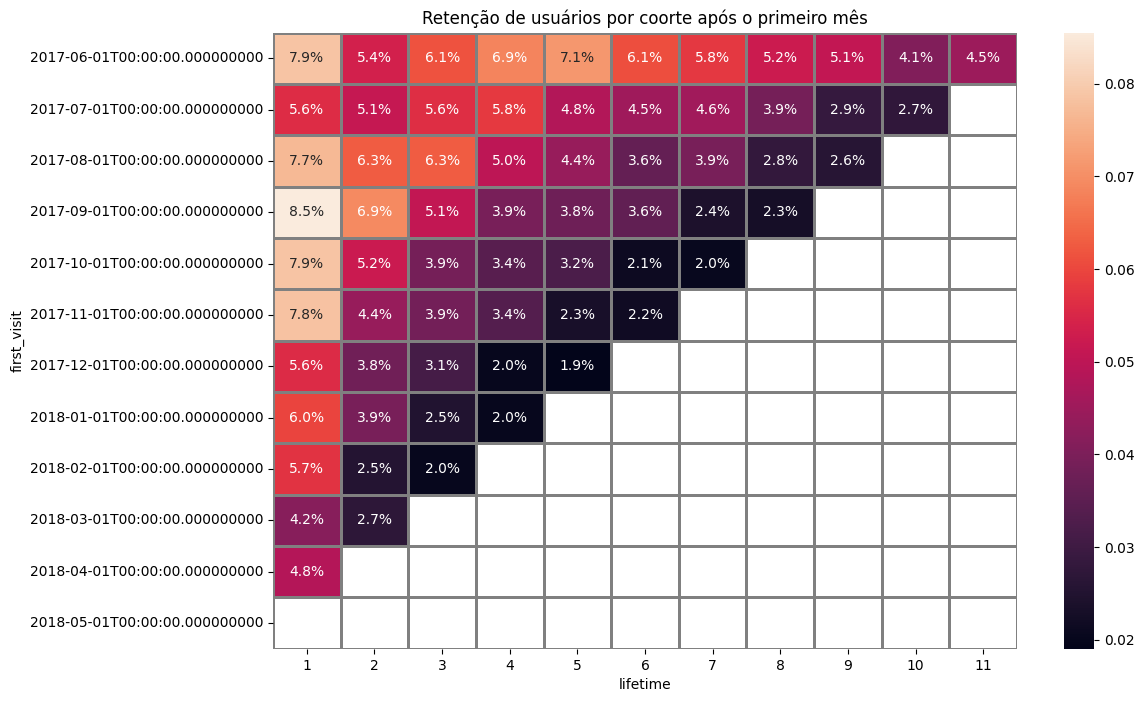

In [32]:
cohorts_pivot_visual = cohorts_pivot.loc[:, 1:]

plt.figure(figsize=(12,8))
plt.title('Retenção de usuários por coorte após o primeiro mês')
sns.heatmap(cohorts_pivot_visual, annot=True, fmt='.1%', linewidths=1, linecolor='gray')
plt.show()

### Interpretação dos dados

* A retenção de usuários é baixa: menos de 10% dos usuários originais de cada coorte voltam a utilizar o site em cada mês após o primeiro.
* Além disso, as coortes mais recentes chegam a níveis muito baixos de retenção mais rapidamente que as coortes mais antigas.

## Conversão: quando as pessoas começam a comprar?

A análise mede o intervalo entre a primeira visita e a primeira compra e compara o comportamento das coortes ao longo do tempo.


In [33]:

#descobrindo número total de compradores por "dias para a compra desde o primeiro acesso"
first_visits = visits_cohorts.groupby('uid')['start_ts'].min().reset_index()
first_buys = orders.groupby('uid')['buy_ts'].min().reset_index()
first_visits_and_buys = pd.merge(first_visits, first_buys, on='uid')
first_visits_and_buys['days_to_convert'] = first_visits_and_buys['buy_ts'].dt.date - first_visits_and_buys['start_ts'].dt.date

first_visits_and_buys['days_to_convert'].value_counts().sort_values(ascending=False)



days_to_convert
0 days      25039
1 days       1966
2 days        685
3 days        452
4 days        386
            ...  
342 days        1
350 days        1
288 days        1
335 days        1
358 days        1
Name: count, Length: 349, dtype: int64

In [34]:
# denominador para taxa de conversão

users_by_cohort = cohorts.groupby('first_visit')['uid'].nunique().reset_index()
users_by_cohort.columns = ['first_visit', 'n_users']
print(users_by_cohort)

   first_visit  n_users
0   2017-06-01    13259
1   2017-07-01    13140
2   2017-08-01    10181
3   2017-09-01    16704
4   2017-10-01    25977
5   2017-11-01    27248
6   2017-12-01    25268
7   2018-01-01    22624
8   2018-02-01    22197
9   2018-03-01    20589
10  2018-04-01    15709
11  2018-05-01    15273


In [35]:
#numerador para taxa de conversão

buyers_with_cohort = pd.merge(first_visits_and_buys, cohorts, on='uid')
buyers_by_cohort = buyers_with_cohort.groupby('first_visit')['uid'].nunique().reset_index()
buyers_by_cohort.columns = ['first_visit', 'n_buyers']
print(buyers_by_cohort)

   first_visit  n_buyers
0   2017-06-01      2923
1   2017-07-01      2458
2   2017-08-01      1721
3   2017-09-01      3058
4   2017-10-01      4678
5   2017-11-01      4262
6   2017-12-01      4074
7   2018-01-01      3119
8   2018-02-01      3186
9   2018-03-01      2838
10  2018-04-01      1890
11  2018-05-01      2316


In [36]:
#taxa de conversão por cohort
convertion_rate = pd.merge(buyers_by_cohort, users_by_cohort, on='first_visit')
convertion_rate['convertion_share'] = (convertion_rate['n_buyers'] / convertion_rate['n_users']) *100

print(convertion_rate)

   first_visit  n_buyers  n_users  convertion_share
0   2017-06-01      2923    13259         22.045403
1   2017-07-01      2458    13140         18.706240
2   2017-08-01      1721    10181         16.904037
3   2017-09-01      3058    16704         18.306992
4   2017-10-01      4678    25977         18.008238
5   2017-11-01      4262    27248         15.641515
6   2017-12-01      4074    25268         16.123160
7   2018-01-01      3119    22624         13.786245
8   2018-02-01      3186    22197         14.353291
9   2018-03-01      2838    20589         13.784059
10  2018-04-01      1890    15709         12.031320
11  2018-05-01      2316    15273         15.164015


In [37]:
convertion_rate_sorted = convertion_rate.sort_values(by='convertion_share', ascending=False)
print(convertion_rate_sorted)

   first_visit  n_buyers  n_users  convertion_share
0   2017-06-01      2923    13259         22.045403
1   2017-07-01      2458    13140         18.706240
3   2017-09-01      3058    16704         18.306992
4   2017-10-01      4678    25977         18.008238
2   2017-08-01      1721    10181         16.904037
6   2017-12-01      4074    25268         16.123160
5   2017-11-01      4262    27248         15.641515
11  2018-05-01      2316    15273         15.164015
8   2018-02-01      3186    22197         14.353291
7   2018-01-01      3119    22624         13.786245
9   2018-03-01      2838    20589         13.784059
10  2018-04-01      1890    15709         12.031320


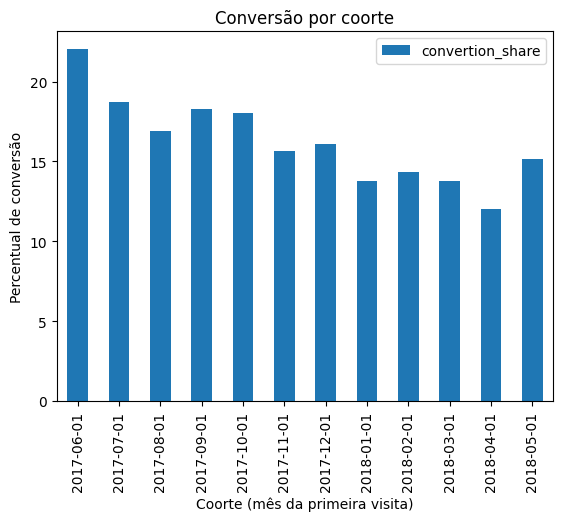

In [38]:
convertion_rate_chrono = convertion_rate.sort_values(by='first_visit')
convertion_rate_chrono['date_first_visit'] = convertion_rate_chrono['first_visit'].dt.date
convertion_rate_chrono.plot(x='date_first_visit', y='convertion_share', xlabel='Coorte (mês da primeira visita)', ylabel='Percentual de conversão', title='Conversão por coorte', kind='bar')
plt.show()

### Interpretação dos dados

A coorte de junho de 2017 apresenta a maior taxa de conversão, cerca de **22%**, enquanto a coorte de abril de 2018 fica em cerca de **12%**. A diferença é relevante, mas deve ser interpretada com cautela: as coortes mais antigas tiveram muito mais tempo para converter do que as mais recentes. Além disso, o resultado mais marcante do tempo até a compra é que a grande maioria das primeiras compras ocorre no **mesmo dia da primeira visita (0d)**.

## Vendas

### Pedidos por cliente ao longo do tempo


**DFS ATÉ O MOMENTO**

**visits**  
1 linha = 1 sessão.  
Serve para analisar usuários, sessões, duração, origem e primeira visita.

**orders**  
1 linha = 1 pedido.  
Serve para analisar compras, compradores, receita e primeira compra.

**costs**  
1 linha = gasto de marketing de uma fonte em uma data.  
Serve para analisar custos, CAC e ROI/ROMI.


**USUÁRIOS / COORTES**

**cohorts**  
1 linha = 1 usuário.  
Guarda a coorte de primeira visita de cada `uid`.

**visits_cohorts**  
1 linha = 1 sessão, já associada à coorte do usuário.  
Serve principalmente para calcular `lifetime` e retenção.

**cohorts_grouped**  
1 linha = 1 combinação coorte + `lifetime`.  
Guarda número de usuários e retenção em cada período.


**VENDAS / CONVERSÃO**

**first_visits_and_buys**  
1 linha = 1 comprador.  
Guarda primeira visita, primeira compra e `days_to_convert`.

**buyers_with_cohort**  
1 linha = 1 comprador, já associado à sua coorte de primeira visita.  
Serve para analisar compradores e tempo de conversão por coorte.

**conversion_rate**  
1 linha = 1 coorte.  
Guarda total de usuários, total de compradores e taxa de conversão da coorte.

In [39]:
# Encontrando numero de pedidos mensais
orders['year_of_buy'] = orders['buy_ts'].dt.year
orders['month_of_buy'] = orders['buy_ts'].dt.month
orders['week_of_buy'] = orders['buy_ts'].dt.isocalendar().week
orders['day_of_buy'] = orders['buy_ts'].dt.date

orders_by_month = orders.groupby(['year_of_buy', 'month_of_buy'])['uid'].count().reset_index()
orders_by_month.columns = ['year', 'month', 'n_orders']

print(orders_by_month.sort_values(by='n_orders', ascending=False))

    year  month  n_orders
6   2017     12      6218
4   2017     10      5679
5   2017     11      5659
9   2018      3      5326
8   2018      2      5281
7   2018      1      4721
11  2018      5      4346
3   2017      9      3387
10  2018      4      3273
1   2017      7      2363
0   2017      6      2354
2   2017      8      1807
12  2018      6         1


In [40]:
#criando coorte por data da primeira compra
orders_cohorts = orders.groupby('uid')['buy_ts'].min().reset_index()
orders_cohorts.columns = ['uid', 'first_buy']

# definindo a coorte pelo mês da primeira compra
orders_cohorts['first_buy_month'] = orders_cohorts['first_buy'].dt.to_period('M').dt.to_timestamp()

print(orders_cohorts)

                        uid           first_buy first_buy_month
0           313578113262317 2018-01-03 21:51:00      2018-01-01
1          1575281904278712 2017-06-03 10:13:00      2017-06-01
2          2429014661409475 2017-10-11 18:33:00      2017-10-01
3          2464366381792757 2018-01-28 15:54:00      2018-01-01
4          2551852515556206 2017-11-24 10:14:00      2017-11-01
...                     ...                 ...             ...
36518  18445147675727495770 2017-11-24 09:03:00      2017-11-01
36519  18445407535914413204 2017-09-22 23:55:00      2017-09-01
36520  18445601152732270159 2018-03-26 22:54:00      2018-03-01
36521  18446156210226471712 2018-02-18 19:34:00      2018-02-01
36522  18446167067214817906 2017-10-17 10:16:00      2017-10-01

[36523 rows x 3 columns]


In [41]:
orders_with_cohort = pd.merge(orders, orders_cohorts, on='uid')

# criando coluna para mês de cada compra
orders_with_cohort['order_month'] = orders_with_cohort['buy_ts'].dt.to_period('M').dt.to_timestamp()

print(orders_with_cohort.head())

               buy_ts  revenue  ...  first_buy_month  order_month
0 2017-06-01 00:10:00    17.00  ...       2017-06-01   2017-06-01
1 2017-06-01 00:25:00     0.55  ...       2017-06-01   2017-06-01
2 2017-06-01 00:27:00     0.37  ...       2017-06-01   2017-06-01
3 2017-06-01 00:29:00     0.55  ...       2017-06-01   2017-06-01
4 2017-06-01 07:58:00     0.37  ...       2017-06-01   2017-06-01

[5 rows x 10 columns]


In [42]:
#criando coluna para exibir tempo de vida de cada usuário
orders_with_cohort['lifetime'] = (orders_with_cohort['order_month'].dt.year - orders_with_cohort['first_buy_month'].dt.year) * 12 + (orders_with_cohort['order_month'].dt.month - orders_with_cohort['first_buy_month'].dt.month)
orders_with_cohort.head()

,buy_ts,revenue,uid,year_of_buy,month_of_buy,week_of_buy,day_of_buy,first_buy,first_buy_month,order_month,lifetime
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017,6,22,2017-06-01,2017-06-01 00:10:00,2017-06-01,2017-06-01,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017,6,22,2017-06-01,2017-06-01 00:25:00,2017-06-01,2017-06-01,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017,6,22,2017-06-01,2017-06-01 00:27:00,2017-06-01,2017-06-01,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017,6,22,2017-06-01,2017-06-01 00:29:00,2017-06-01,2017-06-01,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017,6,22,2017-06-01,2017-06-01 07:58:00,2017-06-01,2017-06-01,0


In [43]:
#exibindo compras por tempo de vida, por coorte
pivot_orders_with_cohort = orders_with_cohort.pivot_table(
    index='first_buy_month',
    columns='lifetime',
    values='uid',
    aggfunc='count'
)

print(pivot_orders_with_cohort)

lifetime             0      1      2      3   ...     8      9     10    11
first_buy_month                               ...                          
2017-06-01       2354.0  177.0  174.0  226.0  ...  212.0  153.0  96.0  86.0
2017-07-01       2186.0  100.0  120.0  104.0  ...   58.0   24.0  53.0   NaN
2017-08-01       1533.0  108.0  100.0   81.0  ...   46.0   46.0   NaN   NaN
2017-09-01       2933.0  219.0  161.0  164.0  ...   61.0    NaN   NaN   NaN
2017-10-01       4964.0  314.0  162.0  122.0  ...    NaN    NaN   NaN   NaN
2017-11-01       4813.0  397.0  182.0  211.0  ...    NaN    NaN   NaN   NaN
2017-12-01       5052.0  270.0  202.0  179.0  ...    NaN    NaN   NaN   NaN
2018-01-01       3783.0  224.0  159.0   64.0  ...    NaN    NaN   NaN   NaN
2018-02-01       4095.0  222.0   83.0   70.0  ...    NaN    NaN   NaN   NaN
2018-03-01       4130.0  178.0  176.0    NaN  ...    NaN    NaN   NaN   NaN
2018-04-01       2495.0  195.0    NaN    NaN  ...    NaN    NaN   NaN   NaN
2018-05-01  

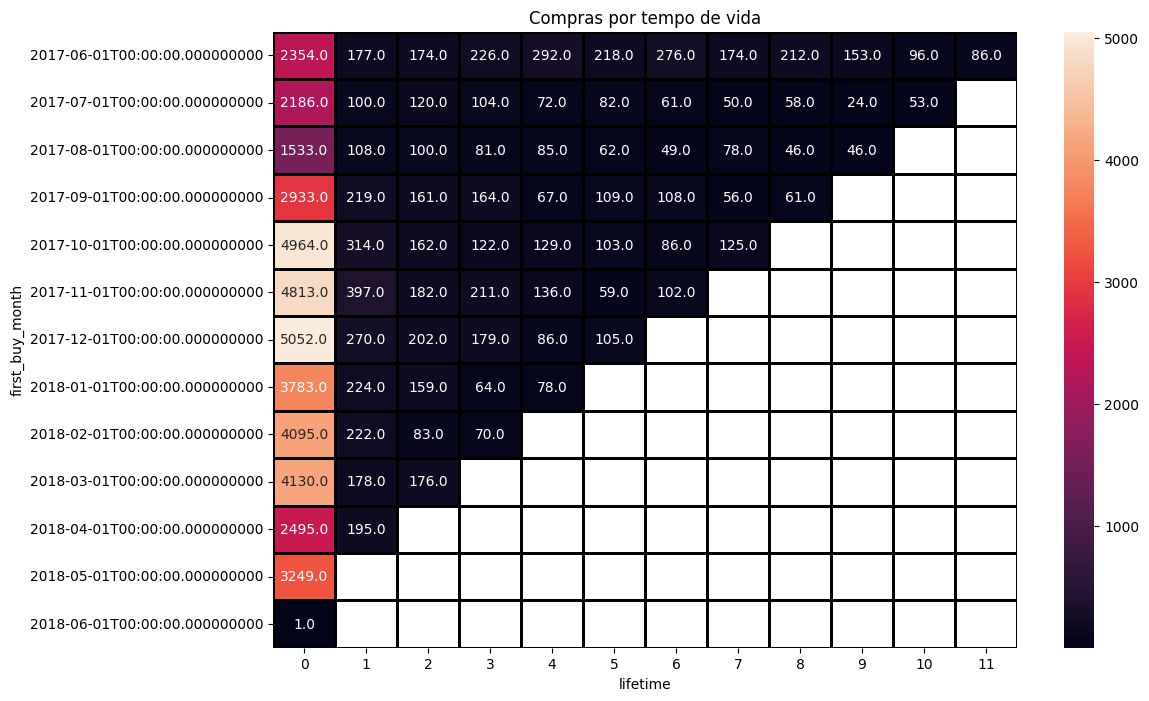

In [44]:
# criando um heatmap para analisar compras por tempo de vida, por coorte
plt.figure(figsize=(12,8))
plt.title('Compras por tempo de vida')
sns.heatmap(pivot_orders_with_cohort, annot=True, fmt='.1f', linewidths=1, linecolor='black')
plt.show()

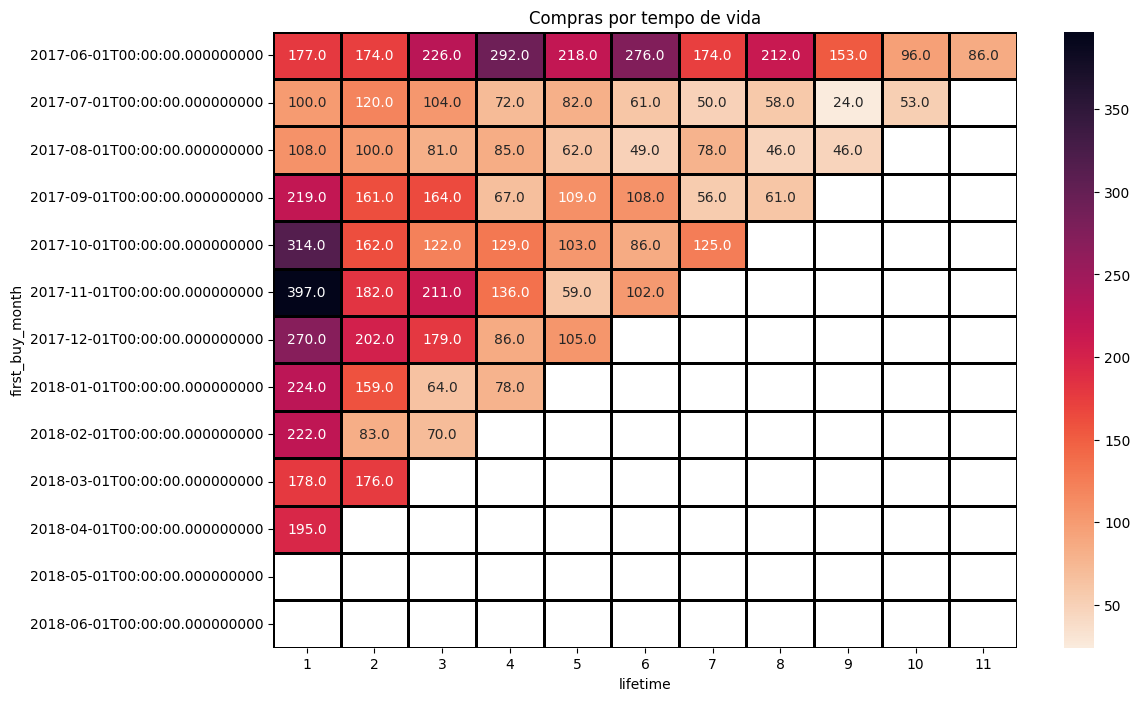

In [45]:
# criando um heatmap sem primeira coluna para melhor visualização
##inverti a paleta de cores

pivot_orders_with_cohort_withoutzero = pivot_orders_with_cohort.loc[:, 1:]

plt.figure(figsize=(12,8))
plt.title('Compras por tempo de vida')

sns.heatmap(
    pivot_orders_with_cohort_withoutzero,
    annot=True,
    fmt='.1f',
    linewidths=1,
    linecolor='black',
    cmap='rocket_r'
)

plt.show()


### Ticket médio


In [46]:
#exibindo renda média por cliente, por corte

average_purchase = orders_with_cohort.groupby(['first_buy_month', 'lifetime']).agg({'revenue' : 'sum', 'uid':'nunique'}).reset_index()
average_purchase['revenue_by_client'] = average_purchase['revenue'] / average_purchase['uid']

print(average_purchase)


   first_buy_month  lifetime   revenue   uid  revenue_by_client
0       2017-06-01         0   9557.49  2023           4.724414
1       2017-06-01         1    981.82    61          16.095410
2       2017-06-01         2    885.34    50          17.706800
3       2017-06-01         3   1931.30    54          35.764815
4       2017-06-01         4   2068.58    88          23.506591
..             ...       ...       ...   ...                ...
74      2018-03-01         2   1114.87    58          19.221897
75      2018-04-01         0  10600.69  2276           4.657597
76      2018-04-01         1   1209.92    69          17.535072
77      2018-05-01         0  13925.76  2988           4.660562
78      2018-06-01         0      3.42     1           3.420000

[79 rows x 5 columns]


In [47]:
#exibindo receita média x cliente por tempo de vida
revenue_by_lifetime = average_purchase.pivot(
    index='first_buy_month',
    columns='lifetime',
    values='revenue_by_client',
)

print(revenue_by_lifetime)

lifetime               0          1          2   ...         9          10        11
first_buy_month                                  ...                                
2017-06-01       4.724414  16.095410  17.706800  ...  27.233556  25.681333  9.804151
2017-07-01       6.010218  12.396346  21.035965  ...  12.861818  11.513846       NaN
2017-08-01       5.276518  11.148793  11.851321  ...   8.307419        NaN       NaN
2017-09-01       5.644529  22.188385  13.445200  ...        NaN        NaN       NaN
2017-10-01       5.003733  11.287427   6.753252  ...        NaN        NaN       NaN
2017-11-01       5.154683   7.339054   6.786583  ...        NaN        NaN       NaN
2017-12-01       4.738191   7.816575  39.366019  ...        NaN        NaN       NaN
2018-01-01       4.135636   8.721228  12.365542  ...        NaN        NaN       NaN
2018-02-01       4.156987   8.610000   4.942414  ...        NaN        NaN       NaN
2018-03-01       4.838803  11.811667  19.221897  ...        NaN  

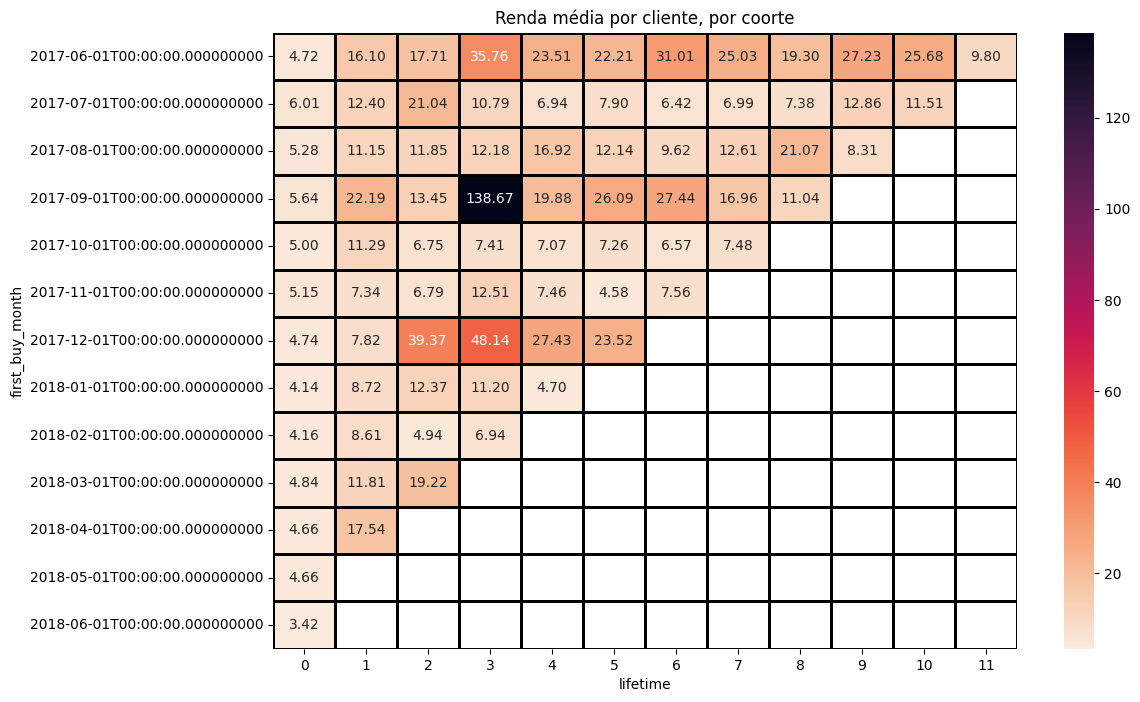

In [48]:
# heatmap de receita média x cliente por tempo de vida
plt.figure(figsize=(12,8))
plt.title('Renda média por cliente, por coorte')

sns.heatmap(
    revenue_by_lifetime,
    annot=True,
    fmt='.2f',
    linewidths=1,
    linecolor='black',
    cmap='rocket_r'
)

plt.show()


4.999646930477041
2.5
0    1.83
Name: revenue, dtype: float64


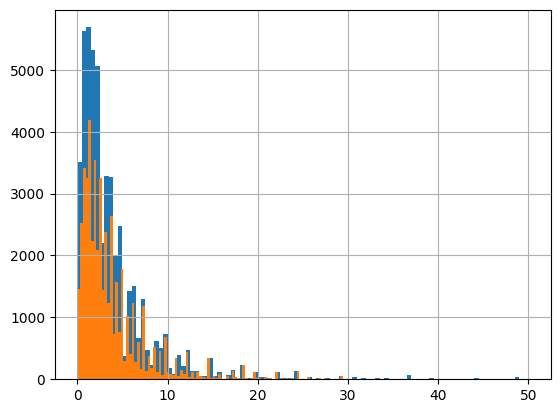

In [49]:
# complementar: histograma, média, mediana e moda

orders_with_cohort['revenue'].hist(bins=100, range=(0,50))
orders_with_cohort['revenue'].hist(bins=100, range=(0,30))

print(orders_with_cohort['revenue'].mean())
print(orders_with_cohort['revenue'].median())
print(orders_with_cohort['revenue'].mode())

### Lifetime Value (LTV)


In [50]:
cohort_sizes = orders_cohorts.groupby('first_buy_month')['uid'].nunique()
revenue_cohort = orders_with_cohort.pivot_table(index='first_buy_month', columns='lifetime', values='revenue', aggfunc='sum')
ltv = revenue_cohort.div(cohort_sizes, axis=0).cumsum(axis=1)
print(ltv)

lifetime               0         1         2   ...         9          10         11
first_buy_month                                ...                                 
2017-06-01       4.724414  5.209743  5.647380  ...  11.051117  11.622378  11.879234
2017-07-01       6.010218  6.345429  6.968960  ...   8.231180   8.386854        NaN
2017-08-01       5.276518  5.748511  6.206993  ...   8.471723        NaN        NaN
2017-09-01       5.644529  6.762115  7.283045  ...        NaN        NaN        NaN
2017-10-01       5.003733  5.539495  5.730889  ...        NaN        NaN        NaN
2017-11-01       5.154683  5.553916  5.753472  ...        NaN        NaN        NaN
2017-12-01       4.738191  4.998565  5.923662  ...        NaN        NaN        NaN
2018-01-01       4.135636  4.430394  4.734675  ...        NaN        NaN        NaN
2018-02-01       4.156987  4.435262  4.513777  ...        NaN        NaN        NaN
2018-03-01       4.838803  5.139694  5.455253  ...        NaN        NaN    

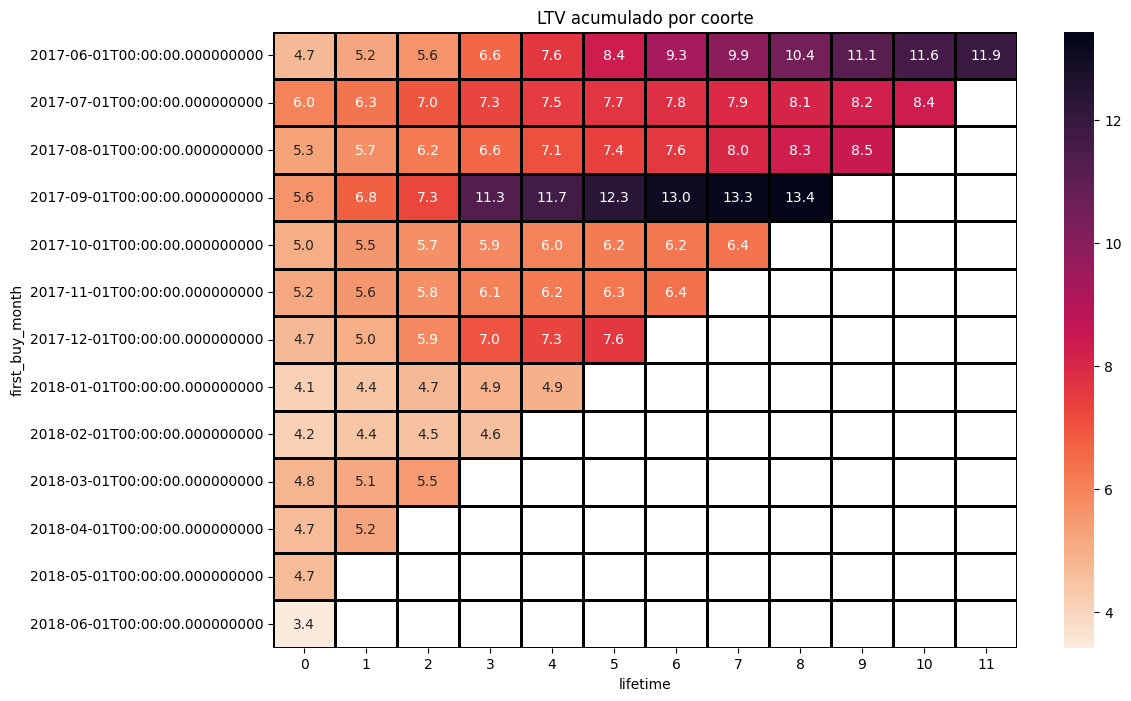

In [51]:
plt.figure(figsize=(12,8))
plt.title('LTV acumulado por coorte')
sns.heatmap(ltv, annot=True, fmt='.1f', linewidths=1, linecolor='black', cmap='rocket_r')
plt.show()

In [52]:
# verificando se o valor atípico da coorte de setembro/2017 no lifetime 3 é puxado por poucos compradores
sept_2017_lifetime3 = orders_with_cohort[(orders_with_cohort['first_buy_month'] == pd.Timestamp('2017-09-01')) & (orders_with_cohort['lifetime'] == 3)]
sept_2017_revenue_by_user = sept_2017_lifetime3.groupby('uid')['revenue'].sum().sort_values(ascending=False)
print(sept_2017_lifetime3['revenue'].describe())
print(sept_2017_revenue_by_user.head())
print('Participação do maior comprador na receita da coorte no período:', sept_2017_revenue_by_user.iloc[0] / sept_2017_lifetime3['revenue'].sum() * 100)

count     164.000000
mean       62.570244
std       237.649021
min         0.030000
25%         1.575000
50%         5.530000
75%        27.577500
max      2633.280000
Name: revenue, dtype: float64
uid
5539673724080479777     9253.70
11218248891942632814     153.26
8539015707073391293      139.12
10246903932085021612     121.67
7137696533349307614      106.64
Name: revenue, dtype: float64
Participação do maior comprador na receita da coorte no período: 90.17864799756762


### Interpretação dos dados

* O dia zero (0d), considerando primeiro acesso e primeira compra dentro do mesmo dia, é disparadamente o período em que mais pessoas fazem a primeira compra: são **25.039 compradores em 0d**, contra **1.966 em 1d**, uma diferença de aproximadamente 12,7 vezes.
* A coorte de junho de 2017 apresenta a maior taxa de conversão, cerca de **22%**, enquanto abril de 2018 fica em cerca de **12%**. Essa comparação deve considerar que as coortes mais antigas tiveram mais tempo para converter.
* Em números absolutos, as vendas se concentram nos últimos e primeiros meses do ano, de outubro a março. Dezembro é o mês com mais vendas, possivelmente com influência do período de fim de ano.
* Na análise de coortes por mês da primeira compra, a coorte mais antiga mantém níveis mais altos de vendas por mais tempo.
* A coorte de setembro de 2017 apresenta uma renda média por cliente muito alta no `lifetime` 3, correspondente a dezembro de 2017. A verificação dos pedidos mostra, porém, que esse resultado é fortemente influenciado por um único comprador, responsável por cerca de 90% da receita da coorte naquele mês; portanto, o valor não representa o comportamento típico da coorte.
* A média geral de receita por pedido ficou em aproximadamente **4,99**, e a mediana em **2,50**. Como a distribuição é fortemente assimétrica à direita, a mediana é uma medida mais representativa do pedido típico.
* Com o LTV corrigido, usando o tamanho inicial de cada coorte como denominador fixo, a coorte de junho de 2017 chega a aproximadamente **11,9** após 12 meses. Entre as coortes com pelo menos seis meses observados, o LTV acumulado médio fica perto de **8**.

## Marketing

### Investimento em marketing por fonte e ao longo do tempo


In [53]:
print(costs.sample(50))

costs['source_id'].unique()

     source_id         dt   costs
1229         4 2017-10-19  287.31
1368         4 2018-03-07  336.61
2291        10 2017-09-21    4.48
1741         5 2018-03-17  120.02
852          3 2017-10-05  765.45
687          2 2018-04-23  135.85
470          2 2017-09-16   77.42
2488        10 2018-04-08    7.30
2181        10 2017-06-03    9.62
617          2 2018-02-10  253.15
1935         9 2017-09-28   17.70
905          3 2017-11-27  831.73
1635         5 2017-12-01  216.67
1429         4 2018-05-09  133.48
235          1 2018-01-22   87.81
592          2 2018-01-16  104.29
2332        10 2017-11-01   17.12
2453        10 2018-03-02   25.15
227          1 2018-01-14   53.25
1674         5 2018-01-09  258.67
2481        10 2018-03-30    1.99
2057         9 2018-01-28   11.48
330          1 2018-04-29   27.32
779          3 2017-07-24  272.24
2156         9 2018-05-09   10.85
2231        10 2017-07-23    9.37
280          1 2018-03-08   56.41
1222         4 2017-10-12   63.37
525          2

['1', '2', '3', '4', '5', '9', '10']
Categories (7, object): ['1', '10', '2', '3', '4', '5', '9']

In [54]:
#quanto dinheiro foi gasto no total?

total_costs_mk = costs['costs'].sum()
print(total_costs_mk)


#quanto dinheiro foi gasto por origem?

by_origin_costs_mk = costs.groupby('source_id')['costs'].sum()
print(by_origin_costs_mk.sort_values(ascending=False))


329131.62
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


In [55]:
costs.info()

print(costs['dt'].min())
print(costs['dt'].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   category      
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 42.7 KB
2017-06-01 00:00:00
2018-05-31 00:00:00


In [56]:
#quanto dinheiro foi gasto ao longo do tempo?
costs['year'] = costs['dt'].dt.year
costs['month'] = costs['dt'].dt.month


costs_by_month = costs.groupby(['year', 'month'])['costs'].sum()

print(costs_by_month)
print(costs_by_month.sort_values(ascending=False))


year  month
2017  6        18015.00
      7        18240.59
      8        14790.54
      9        24368.91
      10       36322.88
      11       37907.88
      12       38315.35
2018  1        33518.52
      2        32723.03
      3        30415.27
      4        22289.38
      5        22224.27
Name: costs, dtype: float64
year  month
2017  12       38315.35
      11       37907.88
      10       36322.88
2018  1        33518.52
      2        32723.03
      3        30415.27
2017  9        24368.91
2018  4        22289.38
      5        22224.27
2017  7        18240.59
      6        18015.00
      8        14790.54
Name: costs, dtype: float64


In [57]:
forvisual_costs_by_month = costs_by_month.reset_index()
forvisual_costs_by_month['year_month'] = forvisual_costs_by_month['year'].astype(str) + '-' + forvisual_costs_by_month['month'].astype(str)
print(forvisual_costs_by_month)

    year  month     costs year_month
0   2017      6  18015.00     2017-6
1   2017      7  18240.59     2017-7
2   2017      8  14790.54     2017-8
3   2017      9  24368.91     2017-9
4   2017     10  36322.88    2017-10
5   2017     11  37907.88    2017-11
6   2017     12  38315.35    2017-12
7   2018      1  33518.52     2018-1
8   2018      2  32723.03     2018-2
9   2018      3  30415.27     2018-3
10  2018      4  22289.38     2018-4
11  2018      5  22224.27     2018-5


<Axes: title={'center': 'Despesas com marketing por mês'}, xlabel='Mês e ano', ylabel='Despesas'>

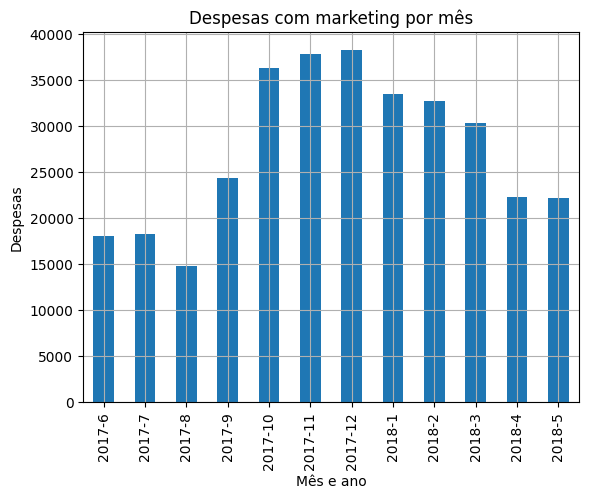

In [58]:
forvisual_costs_by_month.plot(x='year_month', y='costs', kind='bar', xlabel='Mês e ano', ylabel='Despesas', title='Despesas com marketing por mês', legend=False, grid=True )

### Custo de aquisição de clientes (CAC)


In [59]:
#origem da primeira visita

## df cuja linha = 1 comprador com data da primeira visita e data da primeira compra
first_visits_and_buys.head()

## df anterior com source_id
buyers_sources = pd.merge(first_visits_and_buys, visits[['uid', 'start_ts', 'source_id', 'device']],on=['uid', 'start_ts'])
buyers_sources = buyers_sources.rename(columns = {'start_ts':'first_visit', 'buy_ts':'first_buy'})

print(buyers_sources)


## df que contém valores gastos com marketing por origem
by_origin_costs_mk = by_origin_costs_mk.reset_index()
print(by_origin_costs_mk)


                        uid         first_visit  ... source_id   device
0           313578113262317 2017-09-18 22:49:00  ...         2  desktop
1          1575281904278712 2017-06-03 10:13:00  ...        10    touch
2          2429014661409475 2017-10-11 17:14:00  ...         3  desktop
3          2464366381792757 2018-01-27 20:10:00  ...         5  desktop
4          2551852515556206 2017-11-24 10:14:00  ...         5  desktop
...                     ...                 ...  ...       ...      ...
36518  18445147675727495770 2017-08-20 13:30:00  ...         5    touch
36519  18445407535914413204 2017-09-22 23:48:00  ...         3  desktop
36520  18445601152732270159 2017-08-07 11:51:00  ...         2  desktop
36521  18446156210226471712 2017-11-07 10:01:00  ...         3  desktop
36522  18446167067214817906 2017-10-17 10:05:00  ...         5  desktop

[36523 rows x 6 columns]
  source_id      costs
0         1   20833.27
1        10    5822.49
2         2   42806.04
3         3  14132

In [60]:
print(buyers_sources['source_id'].dtype)
print(by_origin_costs_mk['source_id'].dtype)



int64
category


In [61]:
by_origin_costs_mk['source_id'] = by_origin_costs_mk['source_id'].astype(int)

print(buyers_sources['source_id'].dtype)
print(by_origin_costs_mk['source_id'].dtype)



int64
int64


In [62]:
## calculando 
n_buyers_by_sources = buyers_sources.groupby('source_id')['uid'].nunique().reset_index()
n_buyers_by_sources.columns = ['source_id', 'buyers_by_source_id']

costs_by_origin = pd.merge(n_buyers_by_sources, by_origin_costs_mk,on='source_id')
costs_by_origin['cac'] = costs_by_origin['costs'] / costs_by_origin['buyers_by_source_id']


print(costs_by_origin.sort_values(by='cac', ascending=False))

   source_id  buyers_by_source_id      costs        cac
2          3                10473  141321.63  13.493901
1          2                 3506   42806.04  12.209367
4          5                 6931   51757.10   7.467479
0          1                 2899   20833.27   7.186364
3          4                10296   61073.60   5.931779
5          9                 1088    5517.49   5.071222
6         10                 1329    5822.49   4.381106


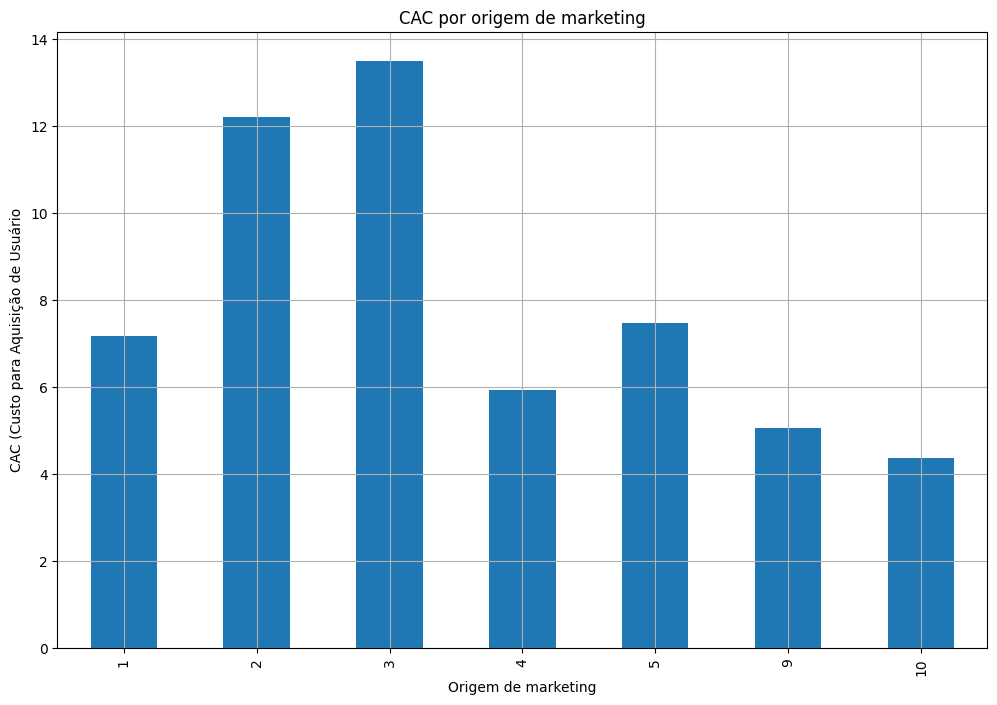

In [63]:
costs_by_origin.plot(x='source_id', y='cac', kind='bar', xlabel='Origem de marketing', ylabel='CAC (Custo para Aquisição de Usuário', title='CAC por origem de marketing', legend=False, grid=True, figsize=(12,8))
plt.show()

### Retorno sobre investimento em marketing (ROMI)


In [64]:
print(first_visits_and_buys)

                        uid  ...    days_to_convert
0           313578113262317  ...  107 days, 0:00:00
1          1575281904278712  ...            0:00:00
2          2429014661409475  ...            0:00:00
3          2464366381792757  ...     1 day, 0:00:00
4          2551852515556206  ...            0:00:00
...                     ...  ...                ...
36518  18445147675727495770  ...   96 days, 0:00:00
36519  18445407535914413204  ...            0:00:00
36520  18445601152732270159  ...  231 days, 0:00:00
36521  18446156210226471712  ...  103 days, 0:00:00
36522  18446167067214817906  ...            0:00:00

[36523 rows x 4 columns]


In [65]:
## acrescentando receita de todos os pedidos dos compradores
orders_first_buy_with_sourceandrevenue = pd.merge(buyers_sources[['uid', 'source_id']], orders[['uid', 'revenue']], on='uid')

## somando receita por origem
orders_first_buy_with_sourceandrevenue = orders_first_buy_with_sourceandrevenue.groupby('source_id')['revenue'].sum().reset_index()
orders_first_buy_with_sourceandrevenue = orders_first_buy_with_sourceandrevenue.rename(columns={'revenue':'income_by_origin'})

## custos e receitas por origem
costs_income_by_origin = pd.merge(orders_first_buy_with_sourceandrevenue, costs_by_origin, on='source_id')
costs_income_by_origin['romi'] = (costs_income_by_origin['income_by_origin'] - costs_income_by_origin['costs']) / costs_income_by_origin['costs']

##métrica mais importante
print(costs_income_by_origin[['source_id', 'romi']].sort_values(by='romi', ascending=False))

##métrica complementar
print(costs_income_by_origin[['source_id', 'income_by_origin']].sort_values(by='income_by_origin', ascending=False))

   source_id      romi
0          1  0.492351
1          2  0.096191
5          9  0.043844
4          5  0.016750
3          4 -0.071664
6         10 -0.235665
2          3 -0.614275
   source_id  income_by_origin
3          4          56696.83
2          3          54511.24
4          5          52624.02
1          2          46923.61
0          1          31090.55
5          9           5759.40
6         10           4450.33


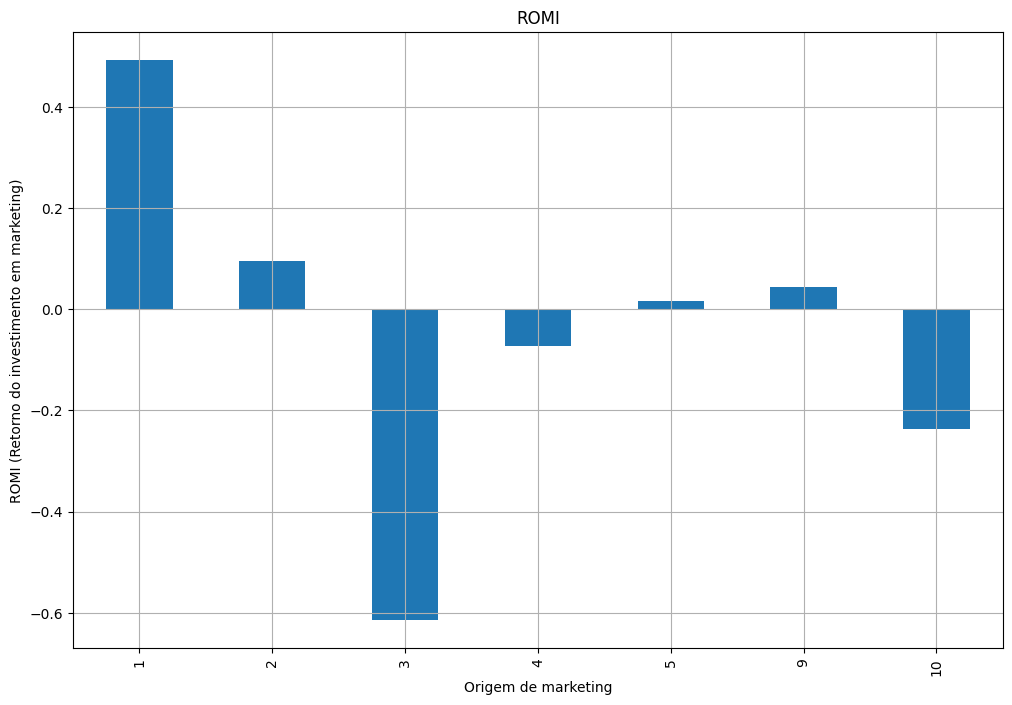

In [66]:
costs_income_by_origin.plot(x='source_id', y='romi', kind='bar', xlabel='Origem de marketing', ylabel='ROMI (Retorno do investimento em marketing)', title='ROMI', legend=False, grid=True, figsize=(12,8))
plt.show()

<Axes: title={'center': 'Renda por origem'}, xlabel='Origem de marketing', ylabel='Renda'>

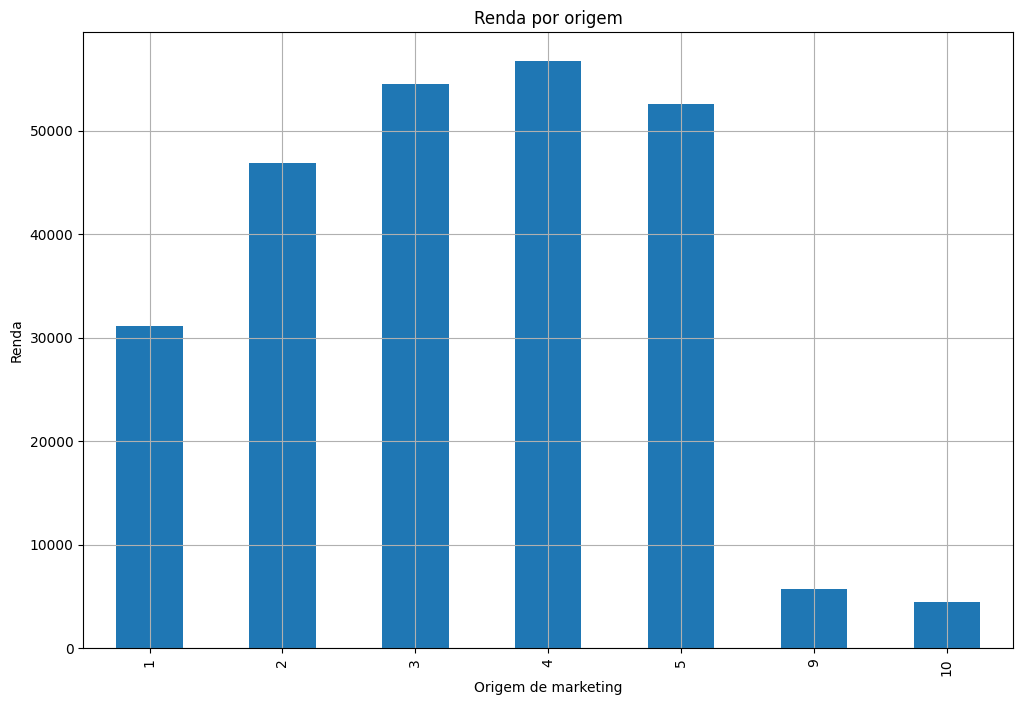

In [67]:
costs_income_by_origin.plot(x='source_id', y='income_by_origin', kind='bar', xlabel='Origem de marketing', ylabel='Renda', title='Renda por origem', legend=False, grid=True, figsize=(12,8))

<Axes: title={'center': 'Despesas x origem de marketing'}, xlabel='Origem de marketing', ylabel='Despesas'>

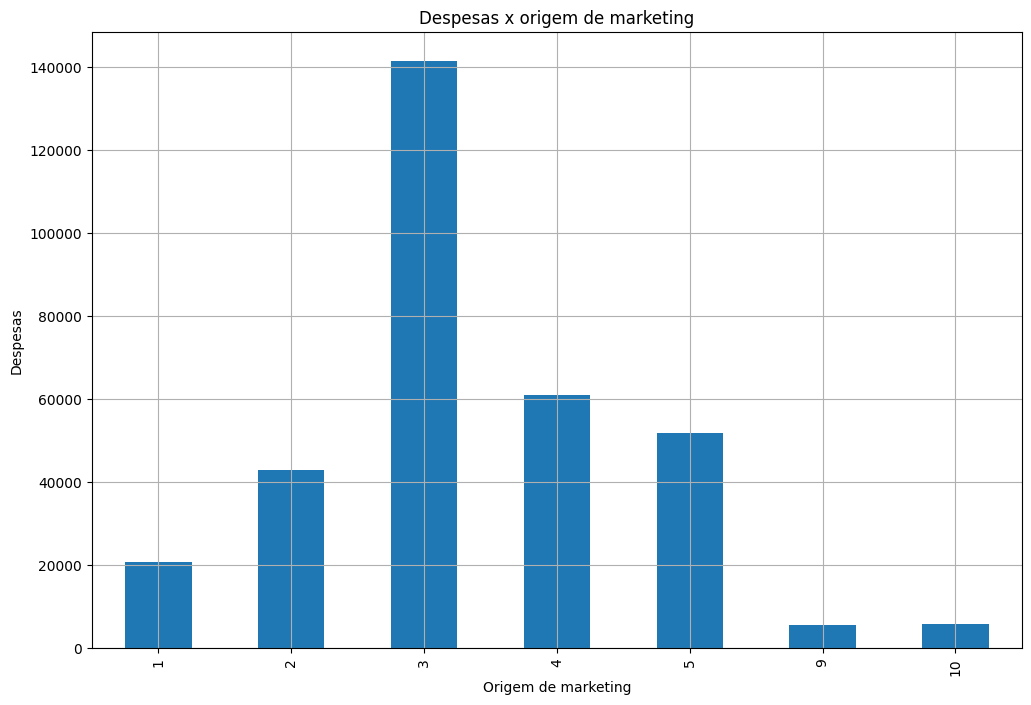

In [68]:
visual_source_id = by_origin_costs_mk.sort_values(by='source_id')
visual_source_id.plot(x='source_id', y='costs', kind='bar', xlabel='Origem de marketing', ylabel='Despesas', title='Despesas x origem de marketing', legend=False, grid=True, figsize=(12,8))

### Síntese de marketing

DESPESAS POR MÊS
* O gráfico das despesas com marketing por mês confirma a concentração de despesas entre outubro e março.

CAC
* As fontes 2 e 3 apresentam CAC superior às demais fontes.

ROMI E RECEITA
* A fonte 1 apresenta o melhor ROMI, cerca de **49%**.
* As fontes 3, 4 e 10 apresentam ROMI negativo, com aproximadamente **-61%**, **-7%** e **-24%**, respectivamente.
* A fonte 4 tem a maior receita absoluta, cerca de **56,7 mil**, e a fonte 3 vem logo atrás, com cerca de **54,5 mil**. A diferença é que a fonte 3 recebeu mais que o dobro do investimento da fonte 4 para gerar uma receita parecida.
* As fontes 5 e 9 têm ROMI positivo, mas muito próximo de zero, cerca de **2%** e **4%**; portanto, qualquer aumento de investimento nelas deve ser tratado como teste.

RECOMENDAÇÕES PRELIMINARES
* Priorizar testes de aumento de investimento na fonte 1.
* Testar com cautela aumentos menores nas fontes 2, 5 e 9.
* Reduzir o peso da fonte 3 e redistribuir parte desse orçamento para as fontes com melhor retorno.
* Reavaliar, em vez de reduzir automaticamente, o investimento na fonte 4, que tem a maior receita e ROMI apenas levemente negativo.
* Reavaliar a fonte 10, que apresenta ROMI negativo e a menor receita absoluta.


## Análise por dispositivo


In [69]:
visits_grouped_device = visits.groupby('device')['source_id'].count().reset_index()
visits_grouped_device.columns = ['device', 'n_sessions']
print(visits_grouped_device)

    device  n_sessions
0  desktop      262567
1    touch       96833


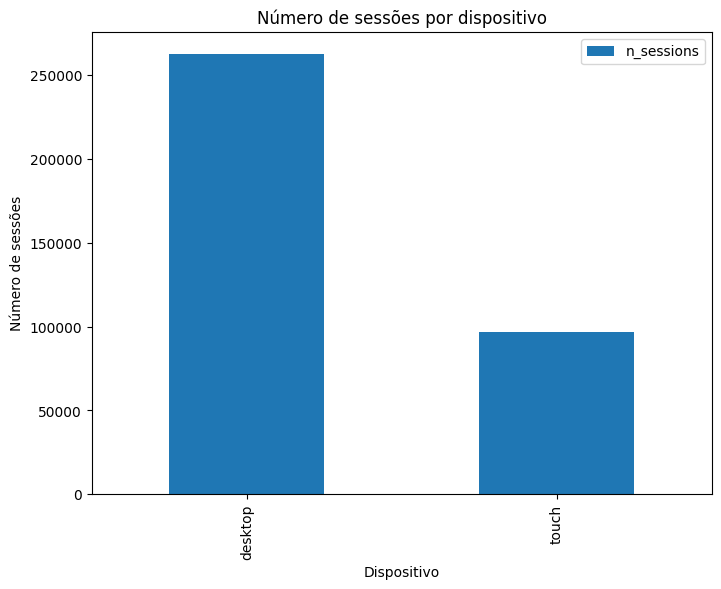

In [70]:
visits_grouped_device.plot(x='device',y='n_sessions',kind='bar',figsize=(8,6),title='Número de sessões por dispositivo', xlabel='Dispositivo', ylabel='Número de sessões')

plt.show()

In [71]:
print(buyers_sources)

                        uid         first_visit  ... source_id   device
0           313578113262317 2017-09-18 22:49:00  ...         2  desktop
1          1575281904278712 2017-06-03 10:13:00  ...        10    touch
2          2429014661409475 2017-10-11 17:14:00  ...         3  desktop
3          2464366381792757 2018-01-27 20:10:00  ...         5  desktop
4          2551852515556206 2017-11-24 10:14:00  ...         5  desktop
...                     ...                 ...  ...       ...      ...
36518  18445147675727495770 2017-08-20 13:30:00  ...         5    touch
36519  18445407535914413204 2017-09-22 23:48:00  ...         3  desktop
36520  18445601152732270159 2017-08-07 11:51:00  ...         2  desktop
36521  18446156210226471712 2017-11-07 10:01:00  ...         3  desktop
36522  18446167067214817906 2017-10-17 10:05:00  ...         5  desktop

[36523 rows x 6 columns]


In [72]:
buyers_by_source_device = buyers_sources.groupby(['source_id', 'device'])['uid'].nunique().reset_index()
buyers_by_source_device.columns = ['source_id', 'device', 'n_buyers']

print(buyers_by_source_device)

    source_id   device  n_buyers
0           1  desktop      2264
1           1    touch       635
2           2  desktop      2649
3           2    touch       857
4           3  desktop      8724
5           3    touch      1749
6           4  desktop      7932
7           4    touch      2364
8           5  desktop      5705
9           5    touch      1226
10          7  desktop         1
11          7    touch         0
12          9  desktop       892
13          9    touch       196
14         10  desktop      1044
15         10    touch       285


In [73]:
buyers_by_source_device = pd.merge(buyers_by_source_device,costs_by_origin[['source_id', 'buyers_by_source_id', 'costs']],on='source_id')
print(buyers_by_source_device)

    source_id   device  n_buyers  buyers_by_source_id      costs
0           1  desktop      2264                 2899   20833.27
1           1    touch       635                 2899   20833.27
2           2  desktop      2649                 3506   42806.04
3           2    touch       857                 3506   42806.04
4           3  desktop      8724                10473  141321.63
5           3    touch      1749                10473  141321.63
6           4  desktop      7932                10296   61073.60
7           4    touch      2364                10296   61073.60
8           5  desktop      5705                 6931   51757.10
9           5    touch      1226                 6931   51757.10
10          9  desktop       892                 1088    5517.49
11          9    touch       196                 1088    5517.49
12         10  desktop      1044                 1329    5822.49
13         10    touch       285                 1329    5822.49


In [74]:
buyers_by_source_device['device_share'] = (buyers_by_source_device['n_buyers']/ buyers_by_source_device['buyers_by_source_id'])
buyers_by_source_device['device_costs'] = (buyers_by_source_device['costs']* buyers_by_source_device['device_share'])

print(buyers_by_source_device)

    source_id   device  n_buyers  ...      costs  device_share   device_costs
0           1  desktop      2264  ...   20833.27      0.780959   16269.928693
1           1    touch       635  ...   20833.27      0.219041    4563.341307
2           2  desktop      2649  ...   42806.04      0.755562   32342.612653
3           2    touch       857  ...   42806.04      0.244438   10463.427347
4           3  desktop      8724  ...  141321.63      0.832999  117720.796345
5           3    touch      1749  ...  141321.63      0.167001   23600.833655
6           4  desktop      7932  ...   61073.60      0.770396   47050.873660
7           4    touch      2364  ...   61073.60      0.229604   14022.726340
8           5  desktop      5705  ...   51757.10      0.823114   42601.970206
9           5    touch      1226  ...   51757.10      0.176886    9155.129794
10          9  desktop       892  ...    5517.49      0.819853    4523.530404
11          9    touch       196  ...    5517.49      0.180147  

In [75]:
buyers_by_source_device['cac'] = (buyers_by_source_device['device_costs']/ buyers_by_source_device['n_buyers'])
print(buyers_by_source_device)

    source_id   device  n_buyers  ...  device_share   device_costs        cac
0           1  desktop      2264  ...      0.780959   16269.928693   7.186364
1           1    touch       635  ...      0.219041    4563.341307   7.186364
2           2  desktop      2649  ...      0.755562   32342.612653  12.209367
3           2    touch       857  ...      0.244438   10463.427347  12.209367
4           3  desktop      8724  ...      0.832999  117720.796345  13.493901
5           3    touch      1749  ...      0.167001   23600.833655  13.493901
6           4  desktop      7932  ...      0.770396   47050.873660   5.931779
7           4    touch      2364  ...      0.229604   14022.726340   5.931779
8           5  desktop      5705  ...      0.823114   42601.970206   7.467479
9           5    touch      1226  ...      0.176886    9155.129794   7.467479
10          9  desktop       892  ...      0.819853    4523.530404   5.071222
11          9    touch       196  ...      0.180147     993.9595

In [76]:
cac_by_device = (buyers_by_source_device.groupby('device').agg({'device_costs':'sum','n_buyers':'sum'}).reset_index())
print(cac_by_device)

    device   device_costs  n_buyers
0  desktop  265083.586724     29210
1    touch   64048.033276      7312


<Axes: title={'center': 'Despesas por dispositivo'}, xlabel='Dispositivo', ylabel='Despesas'>

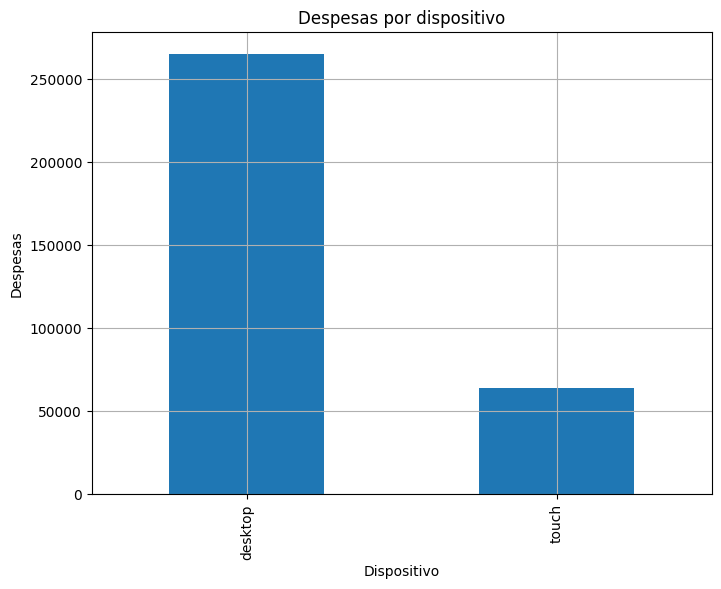

In [77]:
cac_by_device.plot(x='device',y='device_costs',kind='bar',figsize=(8,6),title='Despesas por dispositivo',xlabel='Dispositivo',ylabel='Despesas',legend=False,grid=True)

In [78]:
cac_by_device['cac'] = (cac_by_device['device_costs']/ cac_by_device['n_buyers'])

print(cac_by_device)

    device   device_costs  n_buyers       cac
0  desktop  265083.586724     29210  9.075097
1    touch   64048.033276      7312  8.759304


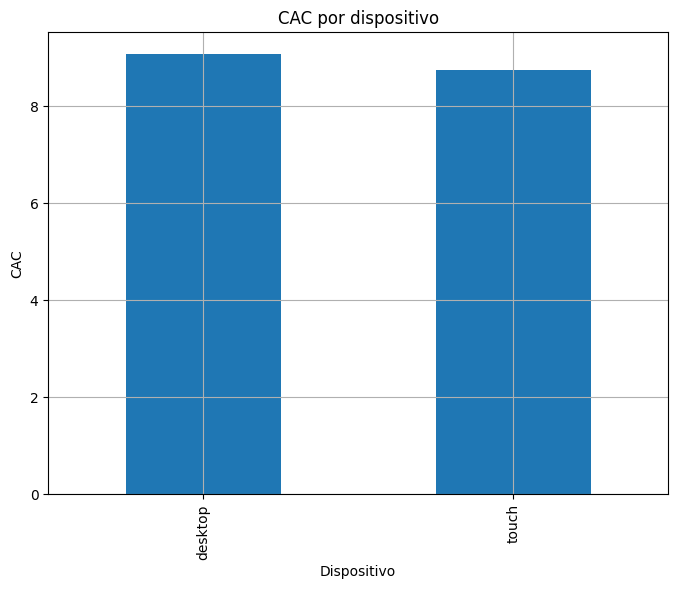

In [79]:
cac_by_device.plot(x='device',y='cac',kind='bar',figsize=(8,6),title='CAC por dispositivo',xlabel='Dispositivo',ylabel='CAC',legend=False,grid=True)

plt.show()

In [80]:
revenue_by_device = pd.merge(buyers_sources[['uid', 'device']],orders[['uid', 'revenue']],on='uid')
print(revenue_by_device)

                        uid   device  revenue
0           313578113262317  desktop     0.55
1          1575281904278712    touch     1.22
2          1575281904278712    touch     1.83
3          2429014661409475  desktop    73.33
4          2464366381792757  desktop     2.44
...                     ...      ...      ...
50410  18445407535914413204  desktop     0.24
50411  18445407535914413204  desktop     0.12
50412  18445601152732270159  desktop     4.22
50413  18446156210226471712  desktop     9.78
50414  18446167067214817906  desktop     7.94

[50415 rows x 3 columns]


In [81]:
revenue_by_device = revenue_by_device.groupby('device').agg({'revenue':'sum'}).reset_index()
romi_by_device = pd.merge(revenue_by_device,cac_by_device, on='device')
romi_by_device['romi'] = (romi_by_device['revenue'] - romi_by_device['device_costs']) / romi_by_device['device_costs']
print(romi_by_device)

    device    revenue   device_costs  n_buyers       cac      romi
0  desktop  211329.77  265083.586724     29210  9.075097 -0.202781
1    touch   40727.43   64048.033276      7312  8.759304 -0.364111


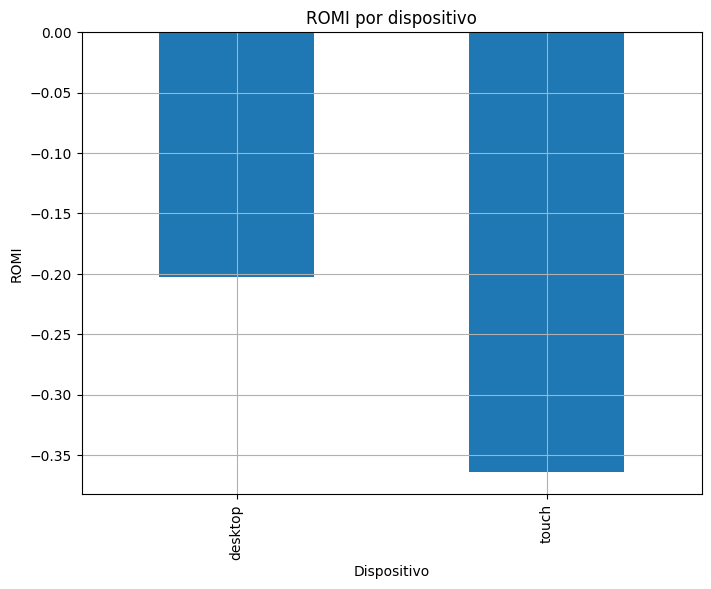

In [82]:
romi_by_device.plot(x='device',y='romi',kind='bar',figsize=(8,6),title='ROMI por dispositivo',xlabel='Dispositivo',ylabel='ROMI',legend=False,grid=True)

plt.show()

### Interpretação dos dados

* Aproximadamente **73% das sessões** ocorrem em desktop e **27% em touch**.
* O CAC calculado por dispositivo deve ser interpretado com cautela, porque o conjunto de dados não informa o gasto real por dispositivo: o custo foi distribuído proporcionalmente à quantidade de compradores. Por construção, dentro de cada fonte o CAC de desktop e touch fica igual, e a pequena diferença agregada entre dispositivos reflete principalmente o mix de fontes.
* O ROMI estimado apresenta diferença relevante: cerca de **-20% em desktop** e **-36% em touch**. Ainda assim, como o custo por dispositivo foi estimado e não observado diretamente, essa comparação não sustenta sozinha uma decisão de redistribuição de orçamento entre dispositivos.

## Conclusão final

Há uma relação entre receita, CAC e ROMI que sugere reavaliação dos investimentos em marketing, em especial na distribuição entre as fontes.

A fonte 1 apresenta o melhor ROMI entre as origens analisadas, cerca de 49%. As fontes 3, 4 e 10 apresentam ROMI negativo. A fonte 3 merece atenção especial: recebe aproximadamente 141,3 mil em investimento, mais que o dobro da fonte 4, mas gera receita parecida, cerca de 54,5 mil contra 56,7 mil da fonte 4. Por isso, a principal recomendação é reduzir o peso da fonte 3 e testar a redistribuição principalmente para a fonte 1. A fonte 4, por sua vez, deve ser reavaliada, e não reduzida automaticamente, pois tem a maior receita e ROMI apenas levemente negativo, cerca de -7%. As fontes 5 e 9 têm retorno positivo, mas próximo de zero, e aumentos nelas devem ser tratados como testes cautelosos.

Com o LTV corrigido, a média acumulada das coortes com pelo menos seis meses de observação fica próxima de 8. Como referência, o CAC das fontes 3 e 2 é de aproximadamente 13,5 e 12,2, acima desse valor; os demais CACs ficam abaixo de 8. Essa comparação é indicativa, pois o LTV foi calculado por coorte temporal e não por fonte de aquisição.

A análise por dispositivo mostra CACs agregados próximos, mas essa semelhança decorre em parte do método de distribuição proporcional dos custos, já que o gasto real por dispositivo não está disponível. O ROMI estimado é mais negativo em touch, cerca de -36%, do que em desktop, cerca de -20%. Aproximadamente 73% das sessões ocorrem em desktop e 27% em touch.

A retenção observada é baixa, sempre abaixo de 10% depois do primeiro mês. Outro dado importante é a forte concentração das primeiras compras em 0d: 25.039 compradores fazem a primeira compra no mesmo dia da primeira visita, contra 1.966 em 1d. Considerando conjuntamente a baixa retenção e a concentração das conversões logo após o primeiro acesso, aumentar a eficiência da aquisição de usuários se torna especialmente importante.

Os dados sustentam principalmente a redução do peso da fonte 3 e testes de redistribuição para a fonte 1, mantendo cautela nas demais fontes e sem tratar as estimativas por dispositivo como custos observados.